# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from abstractgraph_graphicalizer.chem import draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.12.0+cpu
CUDA available: False


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc20'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 7
DATA_LIMIT = 0.99
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
EMBEDDING_DIM = 64
MODEL_NAME = f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=2,
    transformer_attention_head_count=4,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=2,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules


ZINC CSV: /media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/notebooks/datasets/zinc/zinc20.csv
Loaded 69279 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc20-nonstreaming-d64-s0-99-b128-e350 model_dir=/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators


In [4]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=zinc20-nonstreaming-d64-s0-99-b128-e350 model_dir=/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators
Fitting model on 69279 graphs
Fitting feasibility estimator on 69279 graphs
Finished fitting feasibility estimator in 10m 11.5s
Supervision plan:
  node_labels: mode=learned, enabled. 9 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 7742460 pairs (50.00%) from 15484920 total pairs (pos=5162380, neg=10322540, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=2581190, neg=5161270, positive_ratio=0.333.
Trainin

/home/fabrizio/.venvs/py313/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


epoch 1: finished validation in 3.59s
epoch 1: starting validation
epoch 1: finished validation in 98.99s
epoch 1: saving generator snapshot
epoch 1: finished generator snapshot in 10.47s
epoch 2: starting validation
epoch 2: finished validation in 96.94s
epoch 2: saving generator snapshot
epoch 2: finished generator snapshot in 12.67s
epoch 3: starting validation
epoch 3: finished validation in 96.48s
epoch 3: saving generator snapshot
epoch 3: finished generator snapshot in 11.88s
epoch 4: starting validation
epoch 4: finished validation in 98.27s
epoch 4: saving generator snapshot
epoch 4: finished generator snapshot in 13.45s
epoch 5: starting validation
epoch 5: finished validation in 98.27s
epoch 5: saving generator snapshot
epoch 5: finished generator snapshot in 11.72s
epoch 6: starting validation
epoch 6: finished validation in 96.58s
epoch 6: saving generator snapshot
epoch 6: finished generator snapshot in 12.36s
epoch 7: starting validation
epoch 7: finished validation in 9

KeyboardInterrupt: 

In [6]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT='/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = 'zinc20-nonstreaming-d64-s0-99-b128-e350.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)

,name,modified,size_mb
0,zinc20-nonstreaming-d64-s0-99-b128-e350.pkl,2026-05-12 15:39,1087.7
1,zinc18-streaming-d64-s0-9-w2049-b128-e256.pkl,2026-04-02 14:27,36.1
2,zinc15-nonstreaming-d64-s0-99-b128-e350.pkl,2026-04-02 14:27,176.1
3,zinc15-streaming-d64-s0-5-w256-b8-e256.pkl,2026-04-02 04:54,8.1
4,artificial-d32-n86-size8.pkl,2026-03-24 19:40,4.4


Loaded graph generator: zinc20-nonstreaming-d64-s0-99-b128-e350.pkl
/media/fabrizio/06bb7271-2161-43a4-91f1-98f9b67e9ab2/home/fabrizio/code/NodeField/.artifacts/saved_generators/zinc20-nonstreaming-d64-s0-99-b128-e350.pkl


Sampling 7 graphs


Non-streaming ZINC samples without feasibility filtering


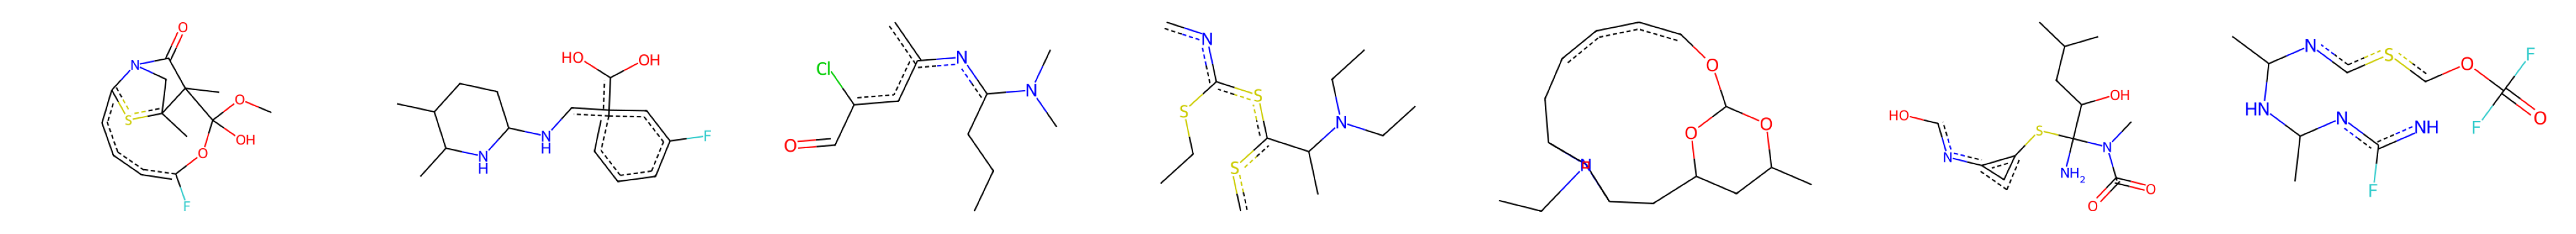

In [7]:
raw_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=7, title='Non-streaming ZINC samples without feasibility filtering')


Sampling 7 graphs
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=9m 53.9s | eta=3h 08m 03.6s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=10m 11.4s | eta=3h 00m 47.9s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 37.1s | eta=2h 03m 00.6s
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=10m 42.3s | eta=3h 23m 24.5s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=6m 37.0s | eta=2h 35m 53.7s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 33.2s | eta=1h 46m 57.7s
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=1m 10.2s | eta=1h 20m 10.8s
Feasibility attempt  5/20 | generated=   8

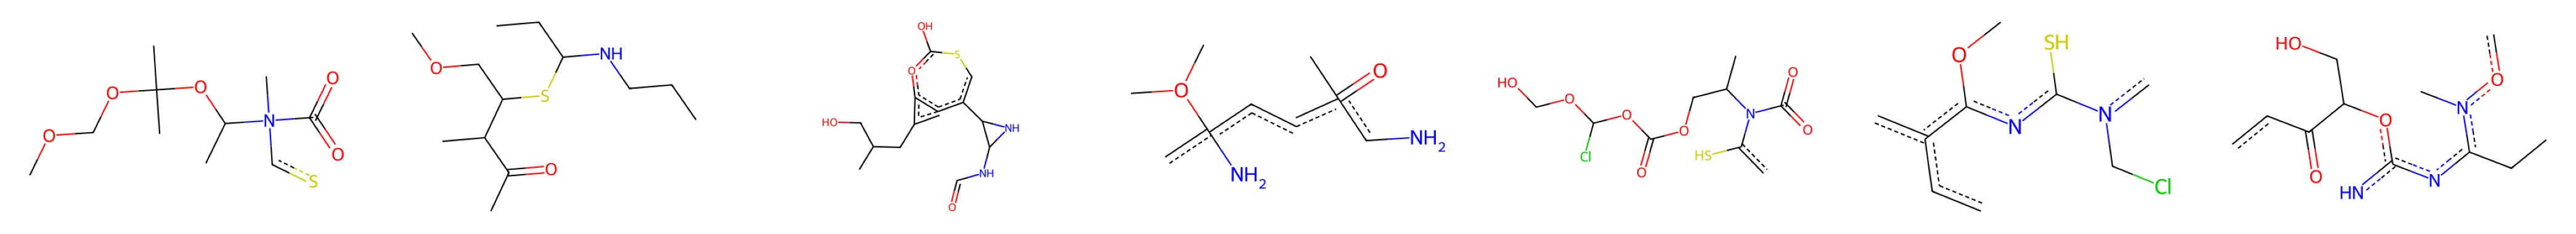

In [8]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=7,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=7, title='Non-streaming ZINC samples with feasibility filtering')
